In [24]:
import pandas as pd

df = pd.read_csv("data/results.csv")

def time_to_seconds(t):
    if pd.isna(t):
        return None
    try:
        parts = [int(p) for p in str(t).split(':')]
        if len(parts) == 3:
            h, m, s = parts
        elif len(parts) == 2:
            h, m, s = 0, *parts
        else:
            return None
        return h*3600 + m*60 + s
    except ValueError:
        return None

for col in ['swimTime', 'bikeTime', 'runTime']:
    df[col + '_sec'] = df[col].apply(time_to_seconds)

finishers = df[df['finishStatus'] == 'Finisher'].dropna(
    subset=['swimTime_sec', 'bikeTime_sec', 'runTime_sec']
).copy()

finishers = finishers.dropna(subset=['Country'])
finishers = finishers[finishers['Country'] != 'Unknown']
finishers = finishers[~finishers['Country'].isin(['-Redacted-', 'WA', 'NT'])]

country_map = {
    'Czechia': 'Czech Republic', 'Schweiz': 'Switzerland',
    'UNITED STATES': 'United States', 'UNITED STATE': 'United States',
    'Argentinia': 'Argentina', 'Deutschland': 'Germany',
    'Russian Federation': 'Russia', 'Taiwan, Province of China': 'Taiwan',
    'Ireland (Republic of)': 'Ireland', 'Réunion': 'Reunion',
    'D': 'Germany', 'F': 'France', 'E': 'Spain', 'ES': 'Spain',
    'B': 'Belgium', 'BE': 'Belgium', 'I': 'Italy', 'A': 'Austria', 'IE': 'Ireland',
    'NSW': 'Australia', 'QLD': 'Australia', 'VIC': 'Australia',
    'SCO': 'Scotland', 'WAL': 'Wales',
}
finishers['Country'] = finishers['Country'].replace(country_map)

print(f"Finisher rows: {len(finishers):,}")
print(f"Unique countries: {finishers['Country'].nunique()}")

Finisher rows: 826,731
Unique countries: 568


In [25]:
MIN_FINISHERS = 200

for col in ['swimTime_sec', 'bikeTime_sec', 'runTime_sec']:
    finishers[col + '_pct'] = finishers.groupby(['raceID', 'Gender'])[col].rank(pct=True)

summary = finishers.groupby(['Country', 'Gender']).agg(
    n=('bib', 'count'),
    swim_pct=('swimTime_sec_pct', 'mean'),
    bike_pct=('bikeTime_sec_pct', 'mean'),
    run_pct=('runTime_sec_pct', 'mean'),
).reset_index()

summary = summary[summary['n'] >= MIN_FINISHERS]
print(f"Countries remaining after filter: {summary['Country'].nunique()}")

Countries remaining after filter: 67


In [26]:
for split, label in [('swim_pct', 'SWIM'), ('bike_pct', 'BIKE'), ('run_pct', 'RUN')]:
    for g in summary['Gender'].unique():
        print(f"\n=== Fastest {label} - Gender: {g} ===")
        top10 = summary[summary['Gender'] == g].sort_values(split).head(10)
        cols = ['Country', 'n', split]
        print(top10[cols])


=== Fastest SWIM - Gender: Male ===
            Country      n  swim_pct
662        Slovenia    956  0.388098
80          Belgium  11250  0.390617
649          Serbia    234  0.403126
156  Czech Republic   2384  0.405027
429           Malta    253  0.408742
297         Hungary    827  0.425147
672           Spain  21988  0.438472
396      Luxembourg    390  0.441652
29          Andorra    212  0.444574
684     Switzerland  10550  0.446629

=== Fastest SWIM - Gender: Female ===
            Country     n  swim_pct
155  Czech Republic   256  0.360174
79          Belgium   994  0.374181
489     Netherlands   969  0.384647
683     Switzerland  2105  0.423073
671           Spain  1185  0.459955
258         Germany  7166  0.462385
43        Australia  9879  0.471195
341           Italy  1451  0.474565
119          Canada  9359  0.475960
92           Brazil  2251  0.476328

=== Fastest BIKE - Gender: Male ===
            Country      n  bike_pct
396      Luxembourg    390  0.358343
80        

In [27]:
summary['overall_pct'] = summary[['swim_pct', 'bike_pct', 'run_pct']].mean(axis=1)

for g in summary['Gender'].unique():
    print(f"\n=== Most consistently fastest OVERALL - Gender: {g} ===")
    top = summary[summary['Gender'] == g].sort_values('overall_pct').head(10)
    cols = ['Country', 'n', 'swim_pct', 'bike_pct', 'run_pct', 'overall_pct']
    print(top[cols])


=== Most consistently fastest OVERALL - Gender: Male ===
            Country      n  swim_pct  bike_pct   run_pct  overall_pct
662        Slovenia    956  0.388098  0.359290  0.370577     0.372655
80          Belgium  11250  0.390617  0.358508  0.391442     0.380189
156  Czech Republic   2384  0.405027  0.367275  0.374082     0.382128
396      Luxembourg    390  0.441652  0.358343  0.393358     0.397784
684     Switzerland  10550  0.446629  0.377816  0.431646     0.418697
201         Estonia   1261  0.464171  0.397467  0.409204     0.423614
386          Latvia    321  0.532731  0.398322  0.359174     0.430076
142      Costa Rica   1001  0.452708  0.437128  0.407825     0.432554
29          Andorra    212  0.444574  0.437271  0.419548     0.433798
740         Ukraine    847  0.460642  0.468974  0.372504     0.434040

=== Most consistently fastest OVERALL - Gender: Female ===
            Country     n  swim_pct  bike_pct   run_pct  overall_pct
155  Czech Republic   256  0.360174  0.3247

In [28]:
races = pd.read_csv("data/races.csv")
finishers_with_year = finishers.merge(races[['id', 'year']], left_on='raceID', right_on='id', how='left')

print("Year range:", finishers_with_year['year'].min(), "-", finishers_with_year['year'].max())
print("\nFinishers per year:")
print(finishers_with_year['year'].value_counts().sort_index())

Year range: 2002 - 2024

Finishers per year:
year
2002     1621
2003     8529
2004     7838
2005    14994
2006    18193
2007    26349
2008    29838
2009    32205
2010    33242
2011    35019
2012    47702
2013    52591
2014    60174
2015    61697
2016    58512
2017    60339
2018    61463
2019    57490
2020     3886
2021    25757
2022    40747
2023    42459
2024    46086
Name: count, dtype: int64


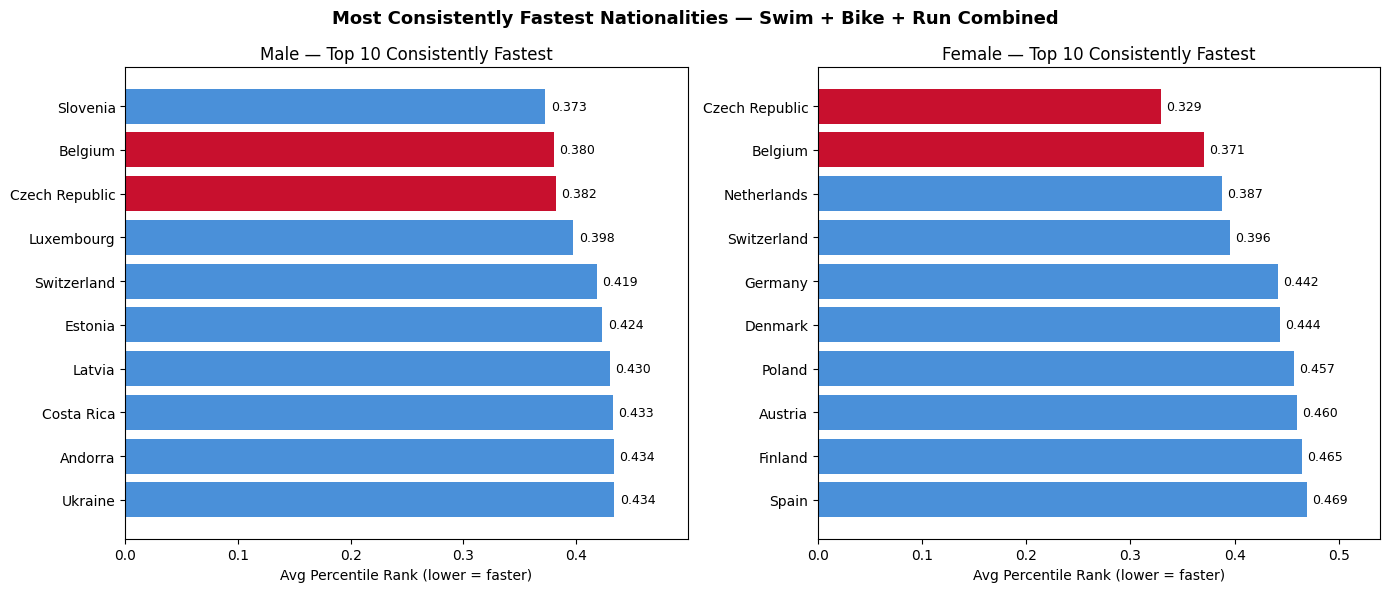

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("images", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gender in zip(axes, ['Male', 'Female']):
    top = summary[summary['Gender'] == gender].sort_values('overall_pct').head(10).iloc[::-1]
    colors = ['#C8102E' if c in ['Belgium', 'Czech Republic'] else '#4A90D9' for c in top['Country']]
    ax.barh(top['Country'], top['overall_pct'], color=colors)
    ax.set_xlabel('Avg Percentile Rank (lower = faster)')
    ax.set_title(f'{gender} — Top 10 Consistently Fastest')
    ax.set_xlim(0, top['overall_pct'].max() * 1.15)
    for i, v in enumerate(top['overall_pct']):
        ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9)

plt.suptitle('Most Consistently Fastest Nationalities — Swim + Bike + Run Combined', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/top10_overall_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

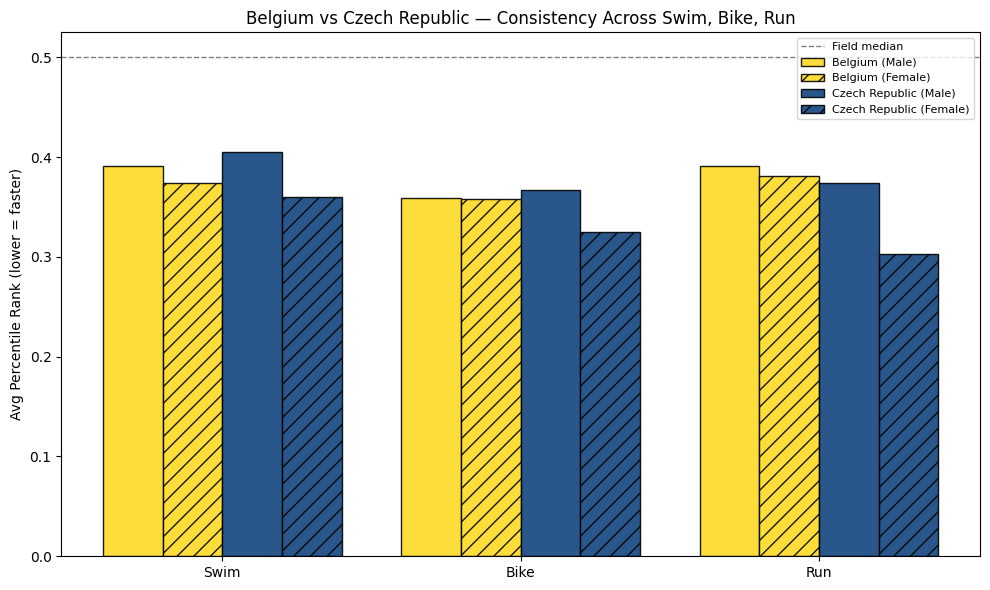

In [30]:
disciplines = [('swim_pct', 'Swim'), ('bike_pct', 'Bike'), ('run_pct', 'Run')]
combos = [('Belgium', 'Male'), ('Belgium', 'Female'), ('Czech Republic', 'Male'), ('Czech Republic', 'Female')]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(disciplines))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
colors = {'Belgium': '#FDDA24', 'Czech Republic': '#11457E'}
hatches = {'Male': None, 'Female': '//'}

for i, (country, gender) in enumerate(combos):
    row = summary[(summary['Country'] == country) & (summary['Gender'] == gender)]
    if row.empty:
        continue
    values = [row[col].values[0] for col, _ in disciplines]
    ax.bar(x + offsets[i]*width, values, width, label=f"{country} ({gender})",
           color=colors[country], hatch=hatches[gender], edgecolor='black', alpha=0.9)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Field median')
ax.set_xticks(x)
ax.set_xticklabels([label for _, label in disciplines])
ax.set_ylabel('Avg Percentile Rank (lower = faster)')
ax.set_title('Belgium vs Czech Republic — Consistency Across Swim, Bike, Run')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('images/belgium_czech_spotlight.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Luj Chan\AppData\Local\Temp\ipykernel_34580\4212528519.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


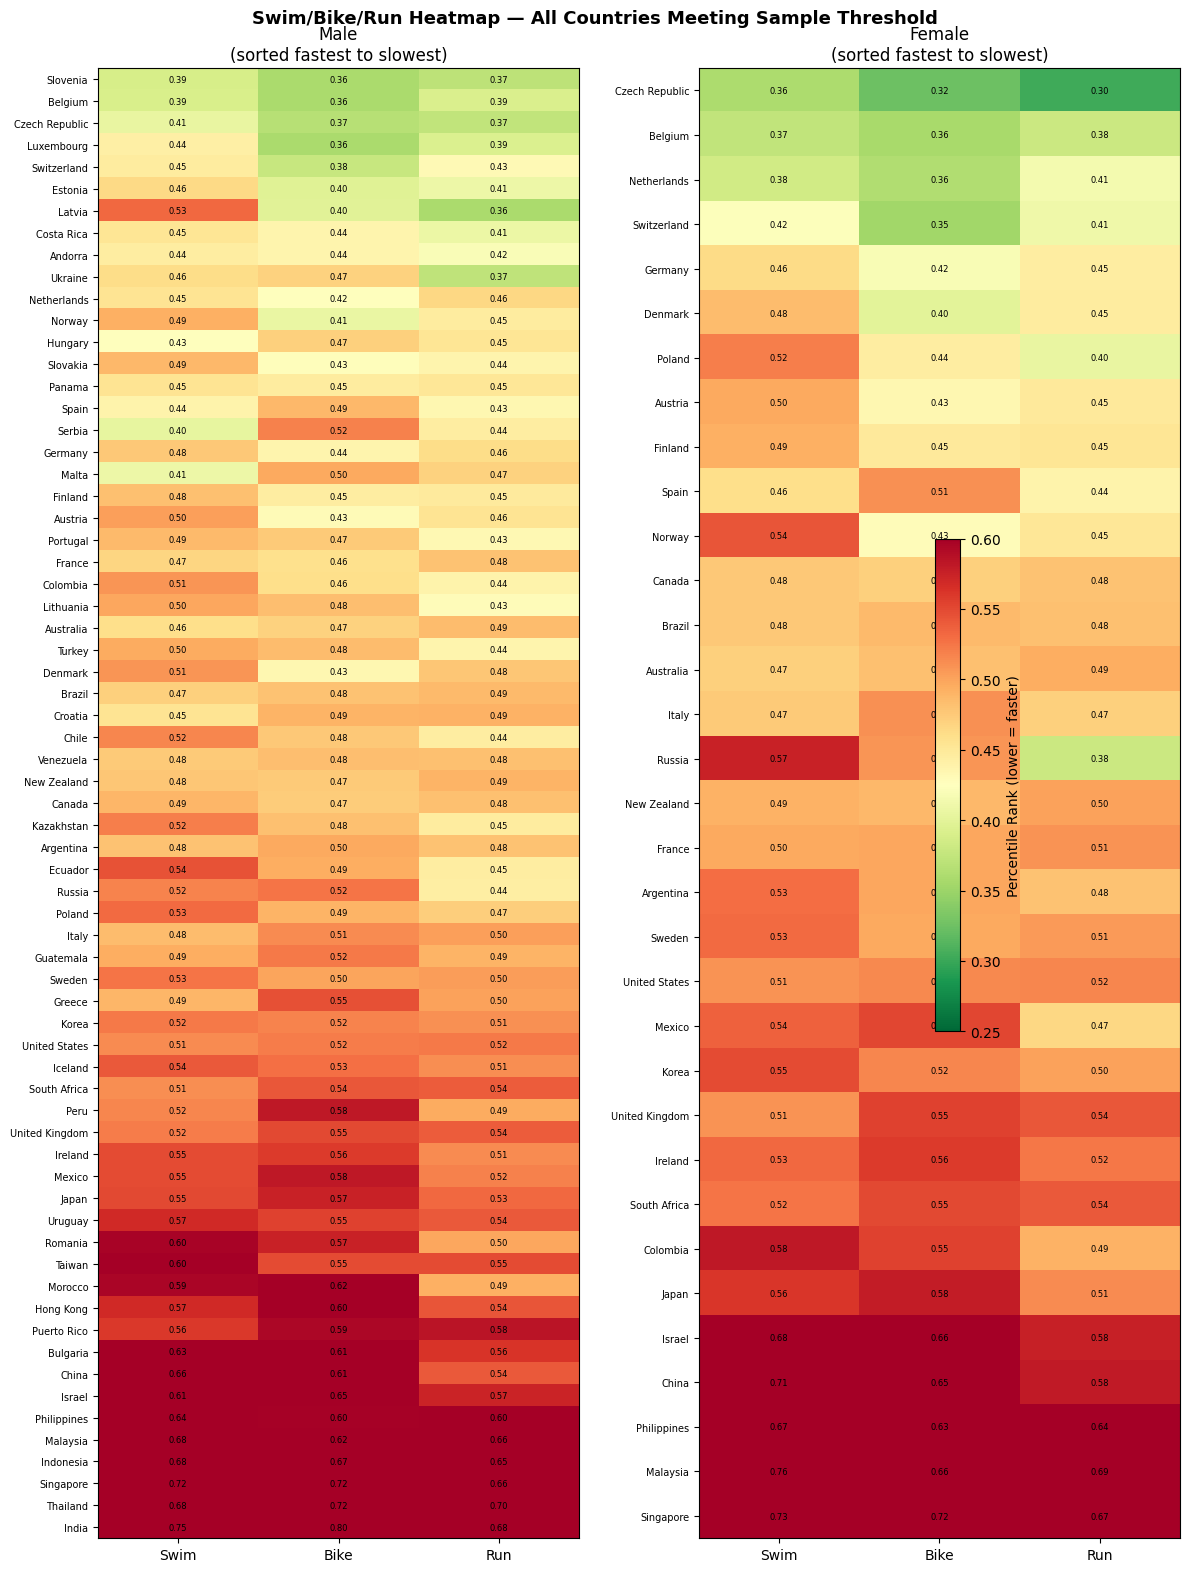

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 16))

for ax, gender in zip(axes, ['Male', 'Female']):
    data = summary[summary['Gender'] == gender].sort_values('overall_pct')
    matrix = data[['swim_pct', 'bike_pct', 'run_pct']].values
    countries = data['Country'].values

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto', vmin=0.25, vmax=0.6)
    ax.set_yticks(range(len(countries)))
    ax.set_yticklabels(countries, fontsize=7)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Swim', 'Bike', 'Run'])
    ax.set_title(f'{gender}\n(sorted fastest to slowest)')

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha='center', va='center', fontsize=6)

fig.colorbar(im, ax=axes, label='Percentile Rank (lower = faster)', shrink=0.4)
plt.suptitle('Swim/Bike/Run Heatmap — All Countries Meeting Sample Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/full_heatmap_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
MIN_FINISHERS = 200

for col in ['swimTime_sec', 'bikeTime_sec', 'runTime_sec']:
    finishers[col + '_pct'] = finishers.groupby(['raceID', 'Gender'])[col].rank(pct=True)

summary = finishers.groupby(['Country', 'Gender']).agg(
    n=('bib', 'count'),
    swim_pct=('swimTime_sec_pct', 'mean'),
    bike_pct=('bikeTime_sec_pct', 'mean'),
    run_pct=('runTime_sec_pct', 'mean'),
).reset_index()

summary = summary[summary['n'] >= MIN_FINISHERS]
print(f"Countries remaining after filter: {summary['Country'].nunique()}")

Countries remaining after filter: 67


In [37]:
for split, label in [('swim_pct', 'SWIM'), ('bike_pct', 'BIKE'), ('run_pct', 'RUN')]:
    for g in summary['Gender'].unique():
        print(f"\n=== Fastest {label} - Gender: {g} ===")
        top10 = summary[summary['Gender'] == g].sort_values(split).head(10)
        cols = ['Country', 'n', split]
        print(top10[cols])


=== Fastest SWIM - Gender: Male ===
            Country      n  swim_pct
662        Slovenia    956  0.388098
80          Belgium  11250  0.390617
649          Serbia    234  0.403126
156  Czech Republic   2384  0.405027
429           Malta    253  0.408742
297         Hungary    827  0.425147
672           Spain  21988  0.438472
396      Luxembourg    390  0.441652
29          Andorra    212  0.444574
684     Switzerland  10550  0.446629

=== Fastest SWIM - Gender: Female ===
            Country     n  swim_pct
155  Czech Republic   256  0.360174
79          Belgium   994  0.374181
489     Netherlands   969  0.384647
683     Switzerland  2105  0.423073
671           Spain  1185  0.459955
258         Germany  7166  0.462385
43        Australia  9879  0.471195
341           Italy  1451  0.474565
119          Canada  9359  0.475960
92           Brazil  2251  0.476328

=== Fastest BIKE - Gender: Male ===
            Country      n  bike_pct
396      Luxembourg    390  0.358343
80        

In [38]:
summary['overall_pct'] = summary[['swim_pct', 'bike_pct', 'run_pct']].mean(axis=1)

for g in summary['Gender'].unique():
    print(f"\n=== Most consistently fastest OVERALL - Gender: {g} ===")
    top = summary[summary['Gender'] == g].sort_values('overall_pct').head(10)
    cols = ['Country', 'n', 'swim_pct', 'bike_pct', 'run_pct', 'overall_pct']
    print(top[cols])


=== Most consistently fastest OVERALL - Gender: Male ===
            Country      n  swim_pct  bike_pct   run_pct  overall_pct
662        Slovenia    956  0.388098  0.359290  0.370577     0.372655
80          Belgium  11250  0.390617  0.358508  0.391442     0.380189
156  Czech Republic   2384  0.405027  0.367275  0.374082     0.382128
396      Luxembourg    390  0.441652  0.358343  0.393358     0.397784
684     Switzerland  10550  0.446629  0.377816  0.431646     0.418697
201         Estonia   1261  0.464171  0.397467  0.409204     0.423614
386          Latvia    321  0.532731  0.398322  0.359174     0.430076
142      Costa Rica   1001  0.452708  0.437128  0.407825     0.432554
29          Andorra    212  0.444574  0.437271  0.419548     0.433798
740         Ukraine    847  0.460642  0.468974  0.372504     0.434040

=== Most consistently fastest OVERALL - Gender: Female ===
            Country     n  swim_pct  bike_pct   run_pct  overall_pct
155  Czech Republic   256  0.360174  0.3247

In [39]:
# --- Drop unknown country ---
finishers = finishers[finishers['Country'] != 'Unknown'].copy()

# --- Check finisher counts per country AND gender ---
gender_counts = finishers.groupby(['Country', 'Gender']).size().unstack(fill_value=0)
gender_counts.columns = ['Female_n', 'Male_n'] if 'F' in finishers['Gender'].unique() else gender_counts.columns
print(gender_counts.sort_values(gender_counts.columns[-1], ascending=False).head(20))

# Adjust this based on what you see above — start conservative
MIN_FINISHERS = 200

# --- Percentile rank: each athlete's split time ranked within their own race + gender ---
# Lower percentile = faster (closer to 0 = near top of the field for that split)
for col in ['swimTime_sec', 'bikeTime_sec', 'runTime_sec']:
    finishers[col + '_pct'] = finishers.groupby(['raceID', 'Gender'])[col].rank(pct=True)

# --- Aggregate by country + gender ---
summary = finishers.groupby(['Country', 'Gender']).agg(
    n=('bib', 'count'),
    swim_pct=('swimTime_sec_pct', 'mean'),
    bike_pct=('bikeTime_sec_pct', 'mean'),
    run_pct=('runTime_sec_pct', 'mean'),
).reset_index()

# Keep only countries with enough finishers PER GENDER
summary = summary[summary['n'] >= MIN_FINISHERS]

# --- Results: top 10 fastest-swimming, fastest-biking, fastest-running nationalities, by gender ---
for split, label in [('swim_pct', 'SWIM'), ('bike_pct', 'BIKE'), ('run_pct', 'RUN')]:
    for g in summary['Gender'].unique():
        print(f"\n=== Fastest {label} — Gender: {g} ===")
        top10 = summary[summary['Gender'] == g].sort_values(split).head(10)
        print(top10[['Country', 'n', split]].to

_IncompleteInputError: incomplete input (4054512621.py, line 33)

In [ ]:
for split, label in [('swim_pct', 'SWIM'), ('bike_pct', 'BIKE'), ('run_pct', 'RUN')]:
    for g in summary['Gender'].unique():
        print(f"\n=== Fastest {label} - Gender: {g} ===")
        top10 = summary[summary['Gender'] == g].sort_values(split).head(10)
        cols = ['Country', 'n', split]
        print(top10[cols])

NameError: name 'summary' is not defined

In [ ]:
summary['overall_pct'] = summary[['swim_pct', 'bike_pct', 'run_pct']].mean(axis=1)

for g in summary['Gender'].unique():
    print(f"\n=== Most consistently fastest OVERALL - Gender: {g} ===")
    top = summary[summary['Gender'] == g].sort_values('overall_pct').head(10)
    cols = ['Country', 'n', 'swim_pct', 'bike_pct', 'run_pct', 'overall_pct']
    print(top[cols])

Gender          Female    Male
Country                       
United States    73367  206130
United Kingdom   10512   65815
Germany           7078   45050
Australia         9742   41993
France            2734   32913
Canada            9359   23437
Spain             1142   21202
Brazil            2251   17930
Italy             1445   16972
Sweden            3225   15802
Denmark           2517   15107
South Africa      3095   14783
Austria           1867   13322
Japan             1892   11998
Mexico            1873   11244
Belgium            978   11033
Switzerland       2041   10275
New Zealand       3237    9849
Ireland           1195    8245
Netherlands        969    6331


In [ ]:
MIN_FINISHERS = 200

for col in ['swimTime_sec', 'bikeTime_sec', 'runTime_sec']:
    finishers[col + '_pct'] = finishers.groupby(['raceID', 'Gender'])[col].rank(pct=True)

summary = finishers.groupby(['Country', 'Gender']).agg(
    n=('bib', 'count'),
    swim_pct=('swimTime_sec_pct', 'mean'),
    bike_pct=('bikeTime_sec_pct', 'mean'),
    run_pct=('runTime_sec_pct', 'mean'),
).reset_index()

summary = summary[summary['n'] >= MIN_FINISHERS]
print(f"Countries remaining after filter: {summary['Country'].nunique()}")

Countries remaining after filter: 78


In [ ]:
for split, label in [('swim_pct', 'SWIM'), ('bike_pct', 'BIKE'), ('run_pct', 'RUN')]:
    for g in summary['Gender'].unique():
        print(f"\n=== Fastest {label} — Gender: {g} ===")
        top10 = summary[summary['Gender'] == g].sort_values(split).head(10)
        cols = ['Country', 'n', split]
        print(top10[cols])
    


=== Fastest SWIM — Gender: Male ===
            Country      n  swim_pct
702        Slovenia    956  0.388098
166  Czech Republic   1633  0.389599
90          Belgium  11033  0.390986
689          Serbia    234  0.403125
457           Malta    253  0.408739
319         Hungary    827  0.425141
712           Spain  21202  0.437049
168         Czechia    751  0.438566
424      Luxembourg    390  0.441645
33          Andorra    212  0.444567

=== Fastest SWIM — Gender: Female ===
         Country     n  swim_pct
89       Belgium   978  0.372585
521  Netherlands   969  0.384648
723  Switzerland  2041  0.421179
711        Spain  1142  0.457520
280      Germany  7078  0.462650
49     Australia  9742  0.470734
369        Italy  1445  0.474858
129       Canada  9359  0.475951
102       Brazil  2251  0.476327
181      Denmark  2517  0.484396

=== Fastest BIKE — Gender: Male ===
            Country      n  bike_pct
166  Czech Republic   1633  0.353090
424      Luxembourg    390  0.358337
90    

In [ ]:
country_map = {
    'Czechia': 'Czech Republic',
    'Schweiz': 'Switzerland',
}
finishers['Country'] = finishers['Country'].replace(country_map)

# Scan for other possible duplicates/variants before moving on
print(sorted(finishers['Country'].unique()))


TypeError: '<' not supported between instances of 'float' and 'str'

In [ ]:
print("Missing country values:", finishers['Country'].isna().sum())

# Drop rows with missing country, then check uniques
finishers = finishers.dropna(subset=['Country'])
print(sorted(finishers['Country'].unique()))

Missing country values: 2
['- Select C', '---', '-Redacted-', '1', '83814', 'A', 'AE', 'AL', 'ALEMANIA', 'AMS', 'AR', 'ARG"', 'ARIZO', 'ARU', 'AT', 'AU', 'AUT (Austria)', 'AZ', 'Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Argentinia', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'B', 'B?LGICA', 'BAHRAIN', 'BAN', 'BAR', 'BAVA', 'BE', 'BIB', 'BIS', 'BIZ', 'BL', 'BOLZANO', 'BRD', 'BRI', 'BRU', 'BRZ', 'BUCHAREST', 'BUEN', 'BUR', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Bavaria', 'Belarus', 'Belgien', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brasilien', 'Brazil', 'British Indian Ocean Territory', 'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'CA', 'CALELLA', 'CAM', 'CAYMAN ISLANDS', 'CDN', 'CDPHP', 'CO', 'CTR', 'CYPRUS', 'CZK', 'CZR', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cape V

In [ ]:
country_value_counts = finishers['Country'].value_counts()
print(country_value_counts[country_value_counts >= 30])


Country
United States                   279548
United Kingdom                   76328
Germany                          52129
Australia                        51735
France                           35647
                                 ...  
Greenland                           33
Liechtenstein                       30
United States Virgin Islands        30
Pakistan                            30
Saipan                              30
Name: count, Length: 154, dtype: int64


In [ ]:
pd.set_option('display.max_rows', None)
print(country_value_counts[country_value_counts >= 30])

Country
United States                           279548
United Kingdom                           76328
Germany                                  52129
Australia                                51735
France                                   35647
Canada                                   32797
Spain                                    22344
Brazil                                   20182
Sweden                                   19027
Italy                                    18417
South Africa                             17878
Denmark                                  17659
Austria                                  15190
Japan                                    13905
Mexico                                   13118
New Zealand                              13086
Switzerland                              12655
Belgium                                  12011
Ireland                                   9440
Netherlands                               7300
Argentinia                                6224
Polan

In [ ]:
country_map = {
    'Czechia': 'Czech Republic',
    'Schweiz': 'Switzerland',
    'UNITED STATES': 'United States',
    'UNITED STATE': 'United States',
    'Argentinia': 'Argentina',          # typo, has MORE rows (6,224) than correct spelling (1,656)!
    'Deutschland': 'Germany',
    'Russian Federation': 'Russia',
    'Taiwan, Province of China': 'Taiwan',
    'Ireland (Republic of)': 'Ireland',
    'Réunion': 'Reunion',               # same place, encoding difference
}

In [ ]:
country_map.update({
    'D': 'Germany', 'F': 'France', 'E': 'Spain', 'ES': 'Spain',
    'B': 'Belgium', 'BE': 'Belgium', 'I': 'Italy', 'A': 'Austria', 'IE': 'Ireland',
})

In [ ]:
country_map.update({
    'NSW': 'Australia', 'QLD': 'Australia', 'VIC': 'Australia',
})

In [ ]:
country_map.update({
    'SCO': 'Scotland', 'WAL': 'Wales',
})

In [ ]:
ambiguous_or_junk = ['-Redacted-', 'WA', 'NT']  # WA = Washington or W.Australia? NT = N.Territory(AUS) or NW Territories(CAN)? Genuinely unresolvable.

In [ ]:
finishers = finishers.dropna(subset=['Country'])
finishers = finishers[finishers['Country'] != 'Unknown']
finishers = finishers[~finishers['Country'].isin(['-Redacted-', 'WA', 'NT'])]
finishers['Country'] = finishers['Country'].replace(country_map)

print(f"Rows remaining: {len(finishers):,}")
print(f"Unique countries remaining: {finishers['Country'].nunique()}")

Rows remaining: 826,731
Unique countries remaining: 568
